## Step 1: Load and Inspect Dataset

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("Churn_Modelling_ML.csv")

print("Dataset shape:", df.shape)
df.head()
df.info()
df.describe()


Dataset shape: (10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## Step 2: Preprocessing

In [3]:
# Drop irrelevant columns
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

# Encode Gender (male=0, female=1)
from sklearn.preprocessing import LabelEncoder
df["Gender"] = LabelEncoder().fit_transform(df["Gender"])

# One-hot encode Geography
df = pd.get_dummies(df, columns=["Geography"], drop_first=True)

print(df.head())


   CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619       0   42       2       0.00              1          1   
1          608       0   41       1   83807.86              1          0   
2          502       0   42       8  159660.80              3          1   
3          699       0   39       1       0.00              2          0   
4          850       0   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  Geography_Spain  
0               1        101348.88       1              False            False  
1               1        112542.58       0              False             True  
2               0        113931.57       1              False            False  
3               0         93826.63       0              False            False  
4               1         79084.10       0              False             True  


## Step 3: Feature Scaling

In [4]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["Exited"])  # Features
y = df["Exited"]                 # Target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## Step 4: Train-Test Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


## Step 5: Train Models

SVM

In [10]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report

# Train SVM with RBF kernel and balanced class weights
svm_model = SVC(kernel="rbf", class_weight="balanced", random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("=== SVM (RBF, balanced) Results ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))


=== SVM (RBF, balanced) Results ===
Confusion Matrix:
 [[1278  329]
 [  99  294]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.80      0.86      1607
           1       0.47      0.75      0.58       393

    accuracy                           0.79      2000
   macro avg       0.70      0.77      0.72      2000
weighted avg       0.84      0.79      0.80      2000



KNN

In [11]:
from sklearn.neighbors import KNeighborsClassifier

# Train KNN with optimal K (from elbow method)
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

print("=== KNN (k=7) Results ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))


=== KNN (k=7) Results ===
Confusion Matrix:
 [[1524   83]
 [ 249  144]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.95      0.90      1607
           1       0.63      0.37      0.46       393

    accuracy                           0.83      2000
   macro avg       0.75      0.66      0.68      2000
weighted avg       0.82      0.83      0.82      2000



## Step 6: Elbow Method for KNN

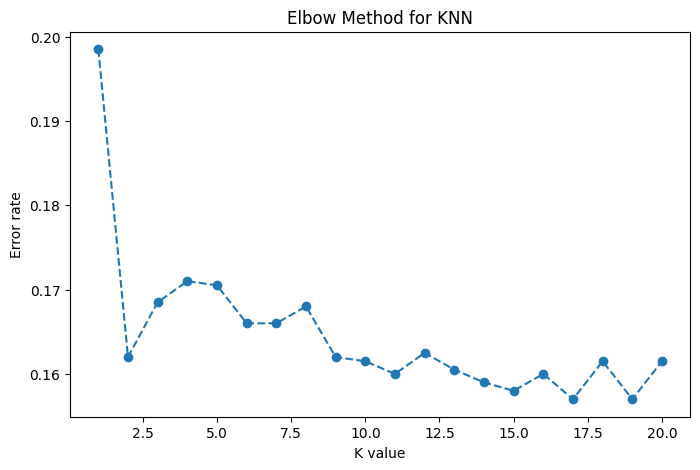

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

error_rates = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    error_rates.append(1 - accuracy_score(y_test, y_pred))

plt.figure(figsize=(8,5))
plt.plot(range(1,21), error_rates, marker='o', linestyle='--')
plt.xlabel("K value")
plt.ylabel("Error rate")
plt.title("Elbow Method for KNN")
plt.show()


## Step 7: Model Evaluation

In [13]:
from sklearn.metrics import confusion_matrix, classification_report

print("=== SVM Results ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))

print("=== KNN Results ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))


=== SVM Results ===
Confusion Matrix:
 [[1278  329]
 [  99  294]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.80      0.86      1607
           1       0.47      0.75      0.58       393

    accuracy                           0.79      2000
   macro avg       0.70      0.77      0.72      2000
weighted avg       0.84      0.79      0.80      2000

=== KNN Results ===
Confusion Matrix:
 [[1524   83]
 [ 249  144]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.95      0.90      1607
           1       0.63      0.37      0.46       393

    accuracy                           0.83      2000
   macro avg       0.75      0.66      0.68      2000
weighted avg       0.82      0.83      0.82      2000



## 8. Conclusion

In this task, we implemented and compared two machine learning models — Support Vector Machine (SVM) and K‑Nearest Neighbors (KNN) — to predict customer churn.

SVM (RBF, balanced) achieved an overall accuracy of ~79%. More importantly, it reached a recall of 0.75 for churners, meaning it correctly identified 75% of customers who were likely to leave. This is crucial in churn prediction, because missing churners directly impacts business retention.

KNN (k=7) achieved a slightly higher accuracy of ~83%, but its recall for churners was only 0.37, meaning it missed many customers who were actually leaving.